In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import itertools
import seaborn as sns

from lifelines.utils import concordance_index
from sksurv.metrics import integrated_brier_score
from models.survite import SurvITE
from tqdm.auto import tqdm
from collections import defaultdict

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET = 'luad'
TREAT_COL_NAME = 'Radiation Therapy'
# TREAT_COL_NAME = 'Radio Therapy'
DATA_PATH = f'data/{DATASET}'

network_settings = {
	'z_dim': 100,
	'h_dim1': 100,
	'h_dim2': 100,
	'num_layers1': 3,
	'num_layers2': 2,
	'active_fn': 'relu',
	'reg_scale': 0,
	'beta': 0.001,
	'ipm_term': 'wasserstein',
	'is_treat': True,
	'is_smoothing': True
}

def load_data(split_dir, modalities):
	"""
	Loads and concatenates specific feature matrices and target variables.
	"""
	# Dynamically load only the requested feature modalities
	X_list = []
	for mod in modalities:
		file_path = os.path.join(split_dir, f'X_{mod}.csv')
		X_list.append(pd.read_csv(file_path, index_col='SAMPLE_ID'))
	
	# Concatenate selected features horizontally
	X = pd.concat(X_list, axis=1).values
	
	# Load targets
	X_treat = pd.read_csv(os.path.join(split_dir, 'X_treat.csv'), index_col='SAMPLE_ID')
	y_df = pd.read_csv(os.path.join(split_dir, 'y.csv'))
	
	T = y_df['time'].values
	E = y_df['event'].values
	A = X_treat[TREAT_COL_NAME].values
	
	return X, T, E, A

In [3]:
def train_and_evaluate(modalities, epochs=100, eval_interval=2, batch_size=256, t_max=50, seed=SEED):
	torch.manual_seed(seed)
	np.random.seed(seed)

	mod_name = " + ".join(modalities)
	
	# 1. Load Data
	X_train, T_train, E_train, A_train = load_data(f'{DATA_PATH}/train', modalities)
	X_test, T_test, E_test, A_test = load_data(f'{DATA_PATH}/test', modalities)
	
	# 2. Time Discretization & Formatting
	max_time = max(T_train.max(), T_test.max())
	time_bins = np.linspace(0, max_time, t_max + 1)
	
	def discretize_time(T, bins):
		T_discrete = np.digitize(T, bins) - 1
		return np.clip(T_discrete, 0, t_max - 1)
	
	T_train_discrete = discretize_time(T_train, time_bins)
	T_test_discrete = discretize_time(T_test, time_bins)
	
	def format_tensor(X, T, E, A):
		return X, np.expand_dims(T, axis=-1), np.expand_dims(E, axis=-1), np.expand_dims(A, axis=-1)
	
	X_train_t, T_train_t, E_train_t, A_train_t = format_tensor(X_train, T_train_discrete, E_train, A_train)
	_, _, _, A_test_t = format_tensor(X_test, T_test_discrete, E_test, A_test)
	
	# 3. Format data for sksurv metrics
	def get_structured_survival_data(E, T):
		return np.array([(bool(e), t) for e, t in zip(E, T)], dtype=[('event', '?'), ('time', '<f8')])
	
	train_survival_sksurv = get_structured_survival_data(E_train, T_train)
	test_survival_sksurv = get_structured_survival_data(E_test, T_test)
	
	min_train_time = T_test[E_test == 1].min() + 1e-5
	max_train_time = T_test.max() - 1e-5
	eval_times = time_bins[1:]
	eval_times = eval_times[(eval_times > min_train_time) & (eval_times < max_train_time)]

	# 4. Model Initialization
	input_dims = {
		'x_dim': X_train.shape[1],
		't_max': t_max,
		'num_Event': 1
	}
	
	model = SurvITE(input_dims, network_settings, device=device)
	optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
	
	# 5. Training Loop
	history = defaultdict(list)
	num_samples = X_train_t.shape[0]
	
	epoch_pbar = tqdm(range(1, epochs + 1), desc=f"Training [{mod_name}] (Features: {X_train.shape[1]})", leave=True)
	
	for epoch in epoch_pbar:
		model.train()
		indices = np.random.permutation(num_samples)
		
		for start_idx in range(0, num_samples, batch_size):
			batch_idx = indices[start_idx:start_idx + batch_size]
			
			model.train_baseline(
				optimizer=optimizer,
				x=X_train_t[batch_idx],
				y=E_train_t[batch_idx],
				t=T_train_t[batch_idx],
				a=A_train_t[batch_idx],
				dropout_rate=0.2
			)
		
		# 6. Evaluation
		if epoch % eval_interval == 0:
			model.eval()
			
			surv_A1 = model.predict_survival_A1(X_test)
			surv_A0 = model.predict_survival_A0(X_test)
			surv_factual = A_test_t * surv_A1 + (1 - A_test_t) * surv_A0
			
			expected_survival_times = np.sum(surv_factual, axis=1)
			c_index = concordance_index(T_test, expected_survival_times, E_test)
			
			eval_indices = discretize_time(eval_times, time_bins)
			surv_estimates_for_ibs = surv_factual[:, eval_indices]

			try:
				ibs_score = integrated_brier_score(
					train_survival_sksurv, test_survival_sksurv, 
					surv_estimates_for_ibs, eval_times
				)
			except Exception:
				ibs_score = float('nan')
			
			history['epoch'].append(epoch)
			history['cidx'].append(c_index)
			history['ibs'].append(ibs_score)

			epoch_pbar.set_postfix({'C-index': f"{c_index:.4f}", 'IBS': f"{ibs_score:.4f}"})
			
	return history

In [4]:
# results_dict = {}
# all_modalities = ['clin', 'diag', 'omics', 'para']
# mod_name = ' + '.join(all_modalities)
# results_dict[mod_name] = train_and_evaluate(all_modalities, epochs=100, eval_interval=2)

In [5]:
all_modalities = ['clin', 'para', 'diag', 'omics']
all_combinations = []

# Generate combos of sizes 1, 2, 3, and 4
for r in range(1, len(all_modalities) + 1):
	all_combinations.extend(itertools.combinations(all_modalities, r))

results_dict = {}

for combo in all_combinations:
	mod_list = list(combo)
	mod_name = " + ".join(mod_list)
	
	# Run training for this specific combination
	# You can reduce 'epochs' here temporarily if you just want to test the loop!
	history = train_and_evaluate(mod_list, epochs=100, eval_interval=2)
	
	results_dict[mod_name] = history

Training [para + diag + omics] (Features: 608): 100%|██████████| 100/100 [00:36<00:00,  2.78it/s, C-index=0.5924, IBS=0.3731]
Training [clin + para + diag + omics] (Features: 621): 100%|██████████| 100/100 [00:36<00:00,  2.76it/s, C-index=0.5531, IBS=0.3071]


In [6]:
cmap = plt.get_cmap("tab20")

def plot_graph(mode, metric):
	plt.figure(figsize=(15, 9))

	count_list = [0, 1, 2]
	if mode == 'single':
		count_list.remove(0)
	elif mode == 'pairwise':
		count_list.remove(1)
	elif mode == 'trimodal':
		count_list.remove(2)
	elif mode == 'all':
		count_list.clear()
	else:
		print("Modes available: single, pairwise, trimodal, all")
		return

	styles = {
		0: {'ls': '-', 'lw': 1.5},
		1: {'ls': ':', 'lw': 2},
		2: {'ls': '--', 'lw': 3},
		3: {'ls': '-', 'lw': 3.5, 'color': 'black'}
	}

	single_colors = {
		'clin': 'C0',
		'para': 'C1',
		'diag': 'C2',
		'omics': 'C3',
	}

	if metric == 'cidx':
		y_axis_name = 'C-index'
	elif metric == 'ibs':
		y_axis_name = 'IBS'

	colors = sns.color_palette('Dark2', n_colors=15)

	for i, (mod_name, hist) in enumerate(results_dict.items()):
		plus_cnt = mod_name.count('+')
		if plus_cnt in count_list:
			continue

		style = styles[plus_cnt]
		if plus_cnt == 0:
			color = single_colors[mod_name]
		else:
			color = style.get('color', colors[i])

		plt.plot(
			hist['epoch'],
			hist[metric],
			label=mod_name,
			color=color,
			linewidth=style['lw'],
			linestyle=style['ls'],
		)
	
	
	plt.title(f"SurvITE - {DATASET} - {mode}")
	plt.xlabel("Epoch")
	plt.ylabel(y_axis_name)
	plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
	plt.grid(True, alpha=0.3)
	plt.tight_layout()
	plt.show()

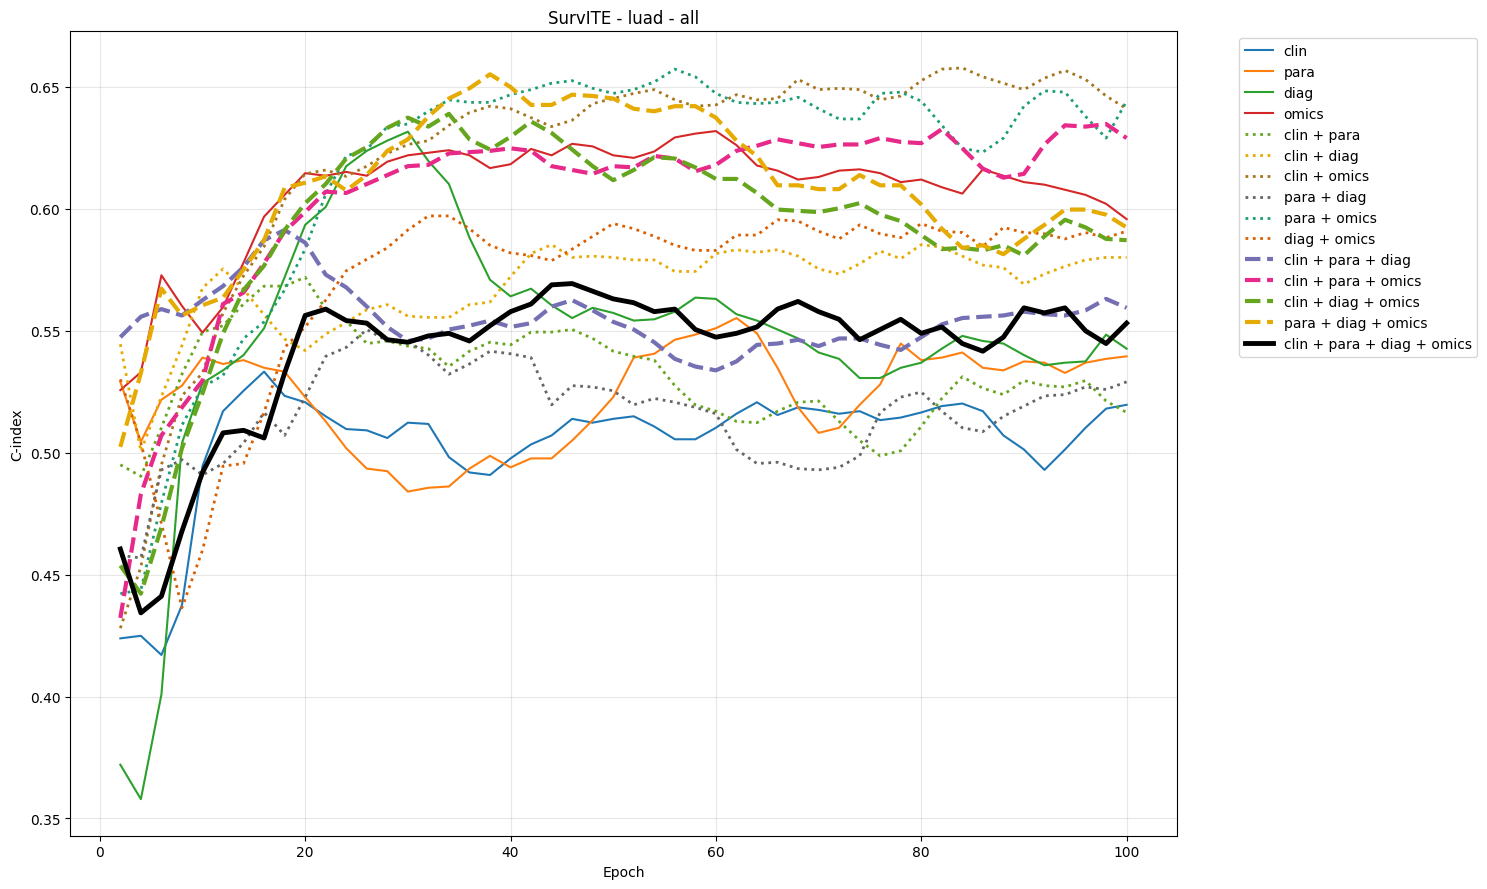

In [7]:
plot_graph('all', 'cidx')

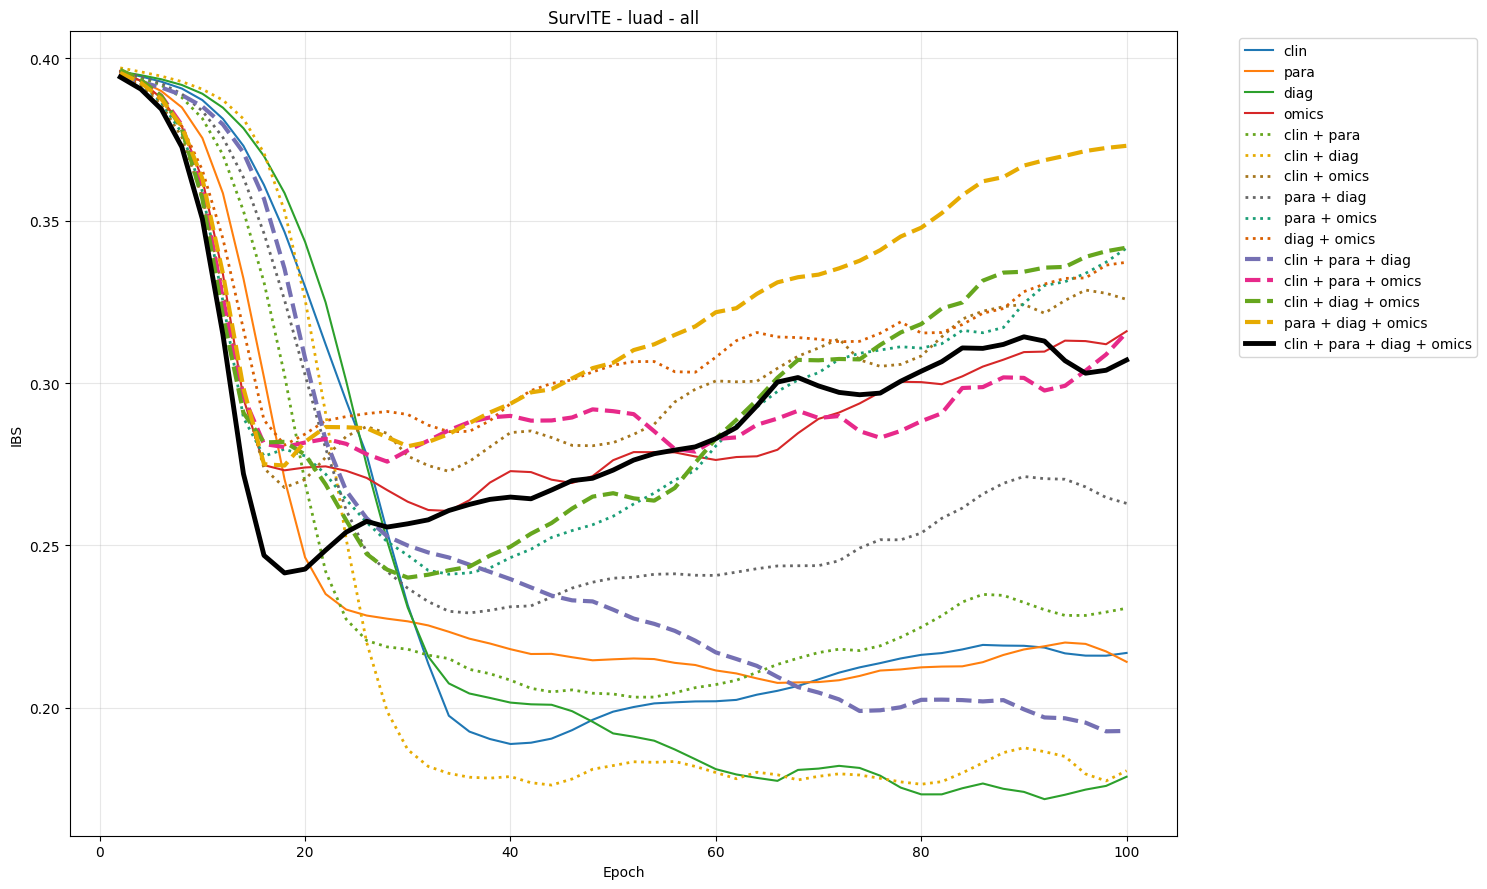

In [8]:
plot_graph('all', 'ibs')